In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import precision_recall_curve, roc_curve, auc, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 4)

In [5]:
# Load the probabilities data for all models
data_dict = {}
model_names = ['3ch', '3ch_res', '6ch']

for model in model_names:
    csv_path = f'../logs/celebdf_ensemble/{model}/probabilities.csv'
    data_dict[model] = pd.read_csv(csv_path)

# Use the first model for display
df = data_dict['3ch']

# Display basic information
print("Dataset Shape:", df.shape)
print("\nFirst few rows:")
print(df.head())
print("\nColumn names:", df.columns.tolist())
print("\nData types:")
print(df.dtypes)
print("\nClass distribution:")
print(df['True_Class'].value_counts())

Dataset Shape: (6766, 6)

First few rows:
   Sample_ID  Real_Probability  Synthesis_Probability Predicted_Class  \
0          0          0.999959               0.000041            Real   
1          1          0.999972               0.000028            Real   
2          2          0.999993               0.000007            Real   
3          3          0.999846               0.000154            Real   
4          4          0.999750               0.000250            Real   

  True_Class  Correct  
0       Real     True  
1       Real     True  
2       Real     True  
3       Real     True  
4       Real     True  

Column names: ['Sample_ID', 'Real_Probability', 'Synthesis_Probability', 'Predicted_Class', 'True_Class', 'Correct']

Data types:
Sample_ID                  int64
Real_Probability         float64
Synthesis_Probability    float64
Predicted_Class              str
True_Class                   str
Correct                     bool
dtype: object

Class distribution:
True_Class


In [6]:
# Prepare data for metrics calculation for all models
metrics_dict = {}
curves_dict = {}

for model in model_names:
    df_model = data_dict[model]
    
    # Create binary labels: 1 for Synthesis, 0 for Real
    y_true = (df_model['True_Class'] == 'Synthesis').astype(int)
    y_scores = df_model['Synthesis_Probability'].values
    
    # Calculate ROC curve metrics
    fpr, tpr, thresholds_roc = roc_curve(y_true, y_scores)
    roc_auc = auc(fpr, tpr)
    
    # Calculate Precision-Recall curve metrics
    precision, recall, thresholds_pr = precision_recall_curve(y_true, y_scores)
    pr_auc = auc(recall, precision)
    
    # Calculate accuracy and other metrics
    tn, fp, fn, tp = confusion_matrix(y_true, (y_scores > 0.5).astype(int)).ravel()
    specificity = tn / (tn + fp)
    sensitivity = tp / (tp + fn)
    
    metrics_dict[model] = {
        'roc_auc': roc_auc,
        'pr_auc': pr_auc,
        'sensitivity': sensitivity,
        'specificity': specificity,
        'tp': tp,
        'tn': tn,
        'fp': fp,
        'fn': fn
    }
    
    curves_dict[model] = {
        'fpr': fpr,
        'tpr': tpr,
        'precision': precision,
        'recall': recall
    }

# Print comparison table
print("=" * 70)
print("Model Performance Comparison")
print("=" * 70)
print(f"{'Model':<15} {'ROC AUC':<12} {'PR AUC':<12} {'Sensitivity':<12} {'Specificity':<12}")
print("-" * 70)
for model in model_names:
    m = metrics_dict[model]
    print(f"{model:<15} {m['roc_auc']:<12.4f} {m['pr_auc']:<12.4f} {m['sensitivity']:<12.4f} {m['specificity']:<12.4f}")
print("=" * 70)

Model Performance Comparison
Model           ROC AUC      PR AUC       Sensitivity  Specificity 
----------------------------------------------------------------------
3ch             0.9982       0.9990       0.9859       0.9827      
3ch_res         0.9746       0.9852       0.9257       0.9134      
6ch             0.9966       0.9981       0.9754       0.9797      


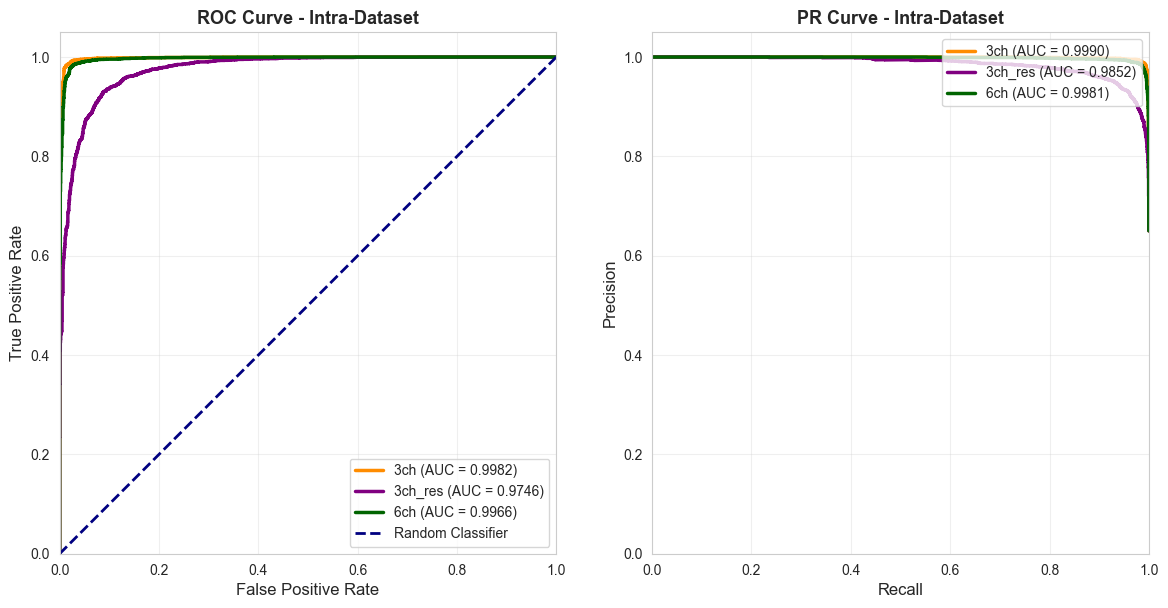

In [9]:
# Plot ROC Curve and Precision-Recall Curve - Model Comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

colors = {'3ch': 'darkorange', '3ch_res': 'purple', '6ch': 'darkgreen'}

# ROC Curve Comparison
for model in model_names:
    curves = curves_dict[model]
    auc_score = metrics_dict[model]['roc_auc']
    axes[0].plot(curves['fpr'], curves['tpr'], color=colors[model], lw=2.5, 
                 label=f'{model} (AUC = {auc_score:.4f})')

axes[0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
axes[0].set_xlim([0.0, 1.0])
axes[0].set_ylim([0.0, 1.05])
axes[0].set_xlabel('False Positive Rate', fontsize=12)
axes[0].set_ylabel('True Positive Rate', fontsize=12)
axes[0].set_title('ROC Curve - Intra-Dataset', fontsize=13, fontweight='bold')
axes[0].legend(loc="lower right", fontsize=10)
axes[0].grid(True, alpha=0.3)
axes[0].set_aspect('equal', adjustable='box')

# Precision-Recall Curve Comparison
for model in model_names:
    curves = curves_dict[model]
    auc_score = metrics_dict[model]['pr_auc']
    axes[1].plot(curves['recall'], curves['precision'], color=colors[model], lw=2.5,
                 label=f'{model} (AUC = {auc_score:.4f})')

axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('Recall', fontsize=12)
axes[1].set_ylabel('Precision', fontsize=12)
axes[1].set_title('PR Curve - Intra-Dataset', fontsize=13, fontweight='bold')
axes[1].legend(loc="upper right", fontsize=10)
axes[1].grid(True, alpha=0.3)
axes[1].set_aspect('equal', adjustable='box')

plt.tight_layout()
plt.show()

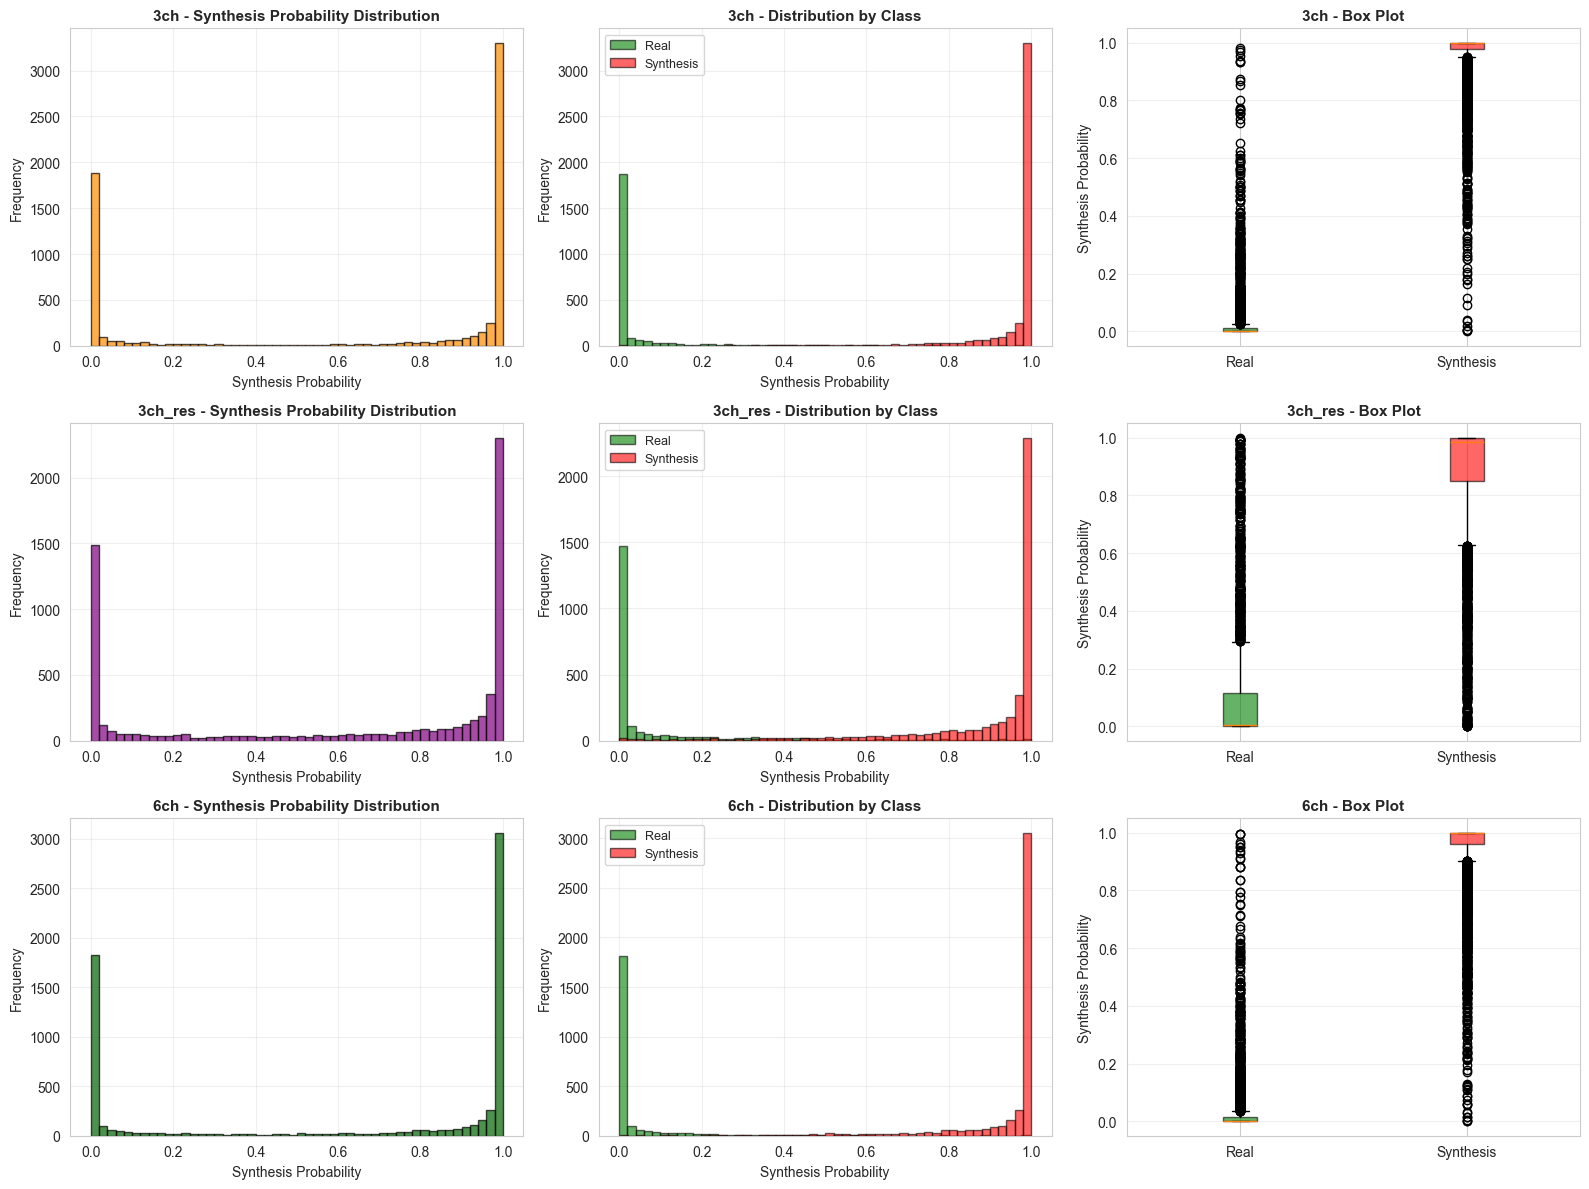


Detailed Probability Statistics by Model

3ch:
  Real samples - Mean: 0.040813, Std: 0.117792, Min: 0.000000, Max: 0.980490
  Synthesis samples - Mean: 0.958664, Std: 0.107947, Min: 0.000077, Max: 1.000000

3ch_res:
  Real samples - Mean: 0.117725, Std: 0.224522, Min: 0.000000, Max: 0.999369
  Synthesis samples - Mean: 0.879107, Std: 0.207173, Min: 0.000011, Max: 1.000000

6ch:
  Real samples - Mean: 0.047728, Std: 0.129552, Min: 0.000000, Max: 0.996303
  Synthesis samples - Mean: 0.939542, Std: 0.137680, Min: 0.000834, Max: 1.000000


In [8]:
# Plot Probability Distribution - Model Comparison
fig, axes = plt.subplots(3, 3, figsize=(16, 12))

for idx, model in enumerate(model_names):
    df_model = data_dict[model]
    
    # Synthesis Probability Distribution for All Samples
    axes[idx, 0].hist(df_model['Synthesis_Probability'], bins=50, color=colors[model], 
                      edgecolor='black', alpha=0.7)
    axes[idx, 0].set_xlabel('Synthesis Probability', fontsize=10)
    axes[idx, 0].set_ylabel('Frequency', fontsize=10)
    axes[idx, 0].set_title(f'{model} - Synthesis Probability Distribution', fontsize=11, fontweight='bold')
    axes[idx, 0].grid(True, alpha=0.3)
    
    # Separate distributions for Real and Synthesis samples
    real_synth_prob = df_model[df_model['True_Class'] == 'Real']['Synthesis_Probability']
    synth_synth_prob = df_model[df_model['True_Class'] == 'Synthesis']['Synthesis_Probability']
    
    axes[idx, 1].hist(real_synth_prob, bins=50, alpha=0.6, label='Real', color='green', edgecolor='black')
    axes[idx, 1].hist(synth_synth_prob, bins=50, alpha=0.6, label='Synthesis', color='red', edgecolor='black')
    axes[idx, 1].set_xlabel('Synthesis Probability', fontsize=10)
    axes[idx, 1].set_ylabel('Frequency', fontsize=10)
    axes[idx, 1].set_title(f'{model} - Distribution by Class', fontsize=11, fontweight='bold')
    axes[idx, 1].legend(fontsize=9)
    axes[idx, 1].grid(True, alpha=0.3)
    
    # Box plot
    data_to_plot = [real_synth_prob, synth_synth_prob]
    bp = axes[idx, 2].boxplot(data_to_plot, labels=['Real', 'Synthesis'], patch_artist=True)
    for patch, color in zip(bp['boxes'], ['green', 'red']):
        patch.set_facecolor(color)
        patch.set_alpha(0.6)
    axes[idx, 2].set_ylabel('Synthesis Probability', fontsize=10)
    axes[idx, 2].set_title(f'{model} - Box Plot', fontsize=11, fontweight='bold')
    axes[idx, 2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Print detailed statistics for each model
print("\n" + "=" * 80)
print("Detailed Probability Statistics by Model")
print("=" * 80)
for model in model_names:
    df_model = data_dict[model]
    real_synth_prob = df_model[df_model['True_Class'] == 'Real']['Synthesis_Probability']
    synth_synth_prob = df_model[df_model['True_Class'] == 'Synthesis']['Synthesis_Probability']
    
    print(f"\n{model}:")
    print(f"  Real samples - Mean: {real_synth_prob.mean():.6f}, Std: {real_synth_prob.std():.6f}, Min: {real_synth_prob.min():.6f}, Max: {real_synth_prob.max():.6f}")
    print(f"  Synthesis samples - Mean: {synth_synth_prob.mean():.6f}, Std: {synth_synth_prob.std():.6f}, Min: {synth_synth_prob.min():.6f}, Max: {synth_synth_prob.max():.6f}")
print("=" * 80)

In [11]:
from sklearn.metrics import f1_score, accuracy_score, precision_score

# Metrics Table at Threshold 0.5
print("\n" + "="*130)
print("COMPREHENSIVE METRICS TABLE (Threshold 0.5)")
print("="*130)

all_metrics = []

for model in model_names:
    df_model = data_dict[model]
    y_true = (df_model['True_Class'] == 'Synthesis').astype(int)
    y_scores = df_model['Synthesis_Probability'].values
    
    # Predictions at threshold 0.5
    y_pred = (y_scores >= 0.5).astype(int)
    
    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    
    # Calculate metrics
    f1 = f1_score(y_true, y_pred)
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    roc_auc = metrics_dict[model]['roc_auc']
    pr_auc = metrics_dict[model]['pr_auc']
    
    all_metrics.append({
        'Model': model,
        'ROC_AUC': roc_auc,
        'PR_AUC': pr_auc,
        'F1_Score': f1,
        'Accuracy': accuracy,
        'Precision': precision,
        'Sensitivity': sensitivity,
        'Specificity': specificity,
        'TP': int(tp),
        'TN': int(tn),
        'FP': int(fp),
        'FN': int(fn)
    })

metrics_table = pd.DataFrame(all_metrics)

# Display table with specified column order
print(f"{'Model':<12} {'ROC_AUC':<12} {'PR_AUC':<12} {'F1_Score':<12} {'Accuracy':<12} {'Precision':<12} {'Sensitivity':<12} {'Specificity':<12} {'TP':<6} {'TN':<6} {'FP':<6} {'FN':<6}")
print("-"*150)
for _, row in metrics_table.iterrows():
    print(f"{row['Model']:<12} {row['ROC_AUC']:<12.4f} {row['PR_AUC']:<12.4f} {row['F1_Score']:<12.4f} {row['Accuracy']:<12.4f} {row['Precision']:<12.4f} {row['Sensitivity']:<12.4f} {row['Specificity']:<12.4f} {row['TP']:<6} {row['TN']:<6} {row['FP']:<6} {row['FN']:<6}")

print("="*150)


COMPREHENSIVE METRICS TABLE (Threshold 0.5)
Model        ROC_AUC      PR_AUC       F1_Score     Accuracy     Precision    Sensitivity  Specificity  TP     TN     FP     FN    
------------------------------------------------------------------------------------------------------------------------------------------------------
3ch          0.9982       0.9990       0.9883       0.9848       0.9906       0.9859       0.9827       4337   2326   41     62    
3ch_res      0.9746       0.9852       0.9387       0.9214       0.9521       0.9257       0.9134       4072   2162   205    327   
6ch          0.9966       0.9981       0.9821       0.9769       0.9889       0.9754       0.9797       4291   2319   48     108   
